In [2]:
%pip install tensorflow matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.19.0-cp39-cp39-macosx_12_0_arm64.whl.metadata (4.0 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached absl_py-2.3.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.29.5-cp38-abi3-macosx_10_9_universal2.whl.metadata (592 bytes)
  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached termcolor-3.1.

In [3]:
import tensorflow as tf
print(tf)

KeyboardInterrupt: 

In [3]:
from tensorflow.keras import layers, models

def build_model(input_shape):
    model = models.Sequential()

    # Input
    model.add(layers.Input(shape=input_shape))

    # Encoder
    model.add(layers.Conv2D(64, (3, 3), strides=2, padding='same', activation='tanh'))
    model.add(layers.BatchNormalization())

    # Instead of GRU, use ConvLSTM2D which maintains spatial structure
    model.add(layers.Reshape((1, 128, 128, 64)))  # Add time dimension
    model.add(layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=False))
    model.add(layers.BatchNormalization())

    # Decoder
    model.add(layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='tanh'))
    model.add(layers.BatchNormalization())

    # Output
    model.add(layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid'))

    return model



In [4]:
from skimage import io
from skimage.transform import resize
image = io.imread('/content/demo.jpg')
image = resize(image, (256,256))

FileNotFoundError: No such file: '/content/demo.jpg'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')
plt.show()

In [65]:
image.shape

(256, 256, 3)

In [66]:
from skimage.transform import radon
from skimage.color import rgb2gray
import numpy as np

# Convert the image to grayscale
image_gray = rgb2gray(image)

# Apply the radon transform to the grayscale image
sinogram = radon(image_gray, theta=np.linspace(0., 180., max(image_gray.shape), endpoint=False), circle = False)

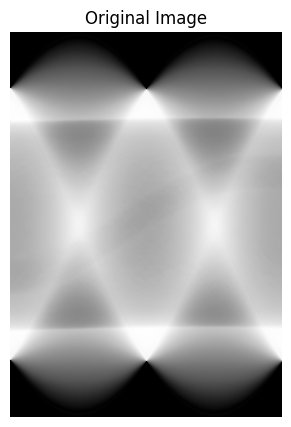

In [67]:
plt.figure(figsize=(10, 5))
# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(sinogram, cmap = plt.cm.Greys_r)
plt.title('Original Image')
plt.axis('off')
plt.show()

In [68]:
sinogram.shape

(363, 256)

In [69]:
# Add a channel dimension to the sinogram
sinogram_with_channel = np.expand_dims(sinogram, axis=-1)

# Build the model with the shape of the sinogram including the channel dimension
model = build_model(sinogram_with_channel.shape)

ValueError: The total size of the tensor must be unchanged. Received: input_shape=(182, 128, 64), target_shape=(23168, 64)

In [ ]:
sinogram_with_channel.shape

In [ ]:
model.summary()

### Displaying Prediction on sample input

In [70]:
# Add a batch dimension to the sinogram for prediction
sinogram_with_batch = np.expand_dims(sinogram_with_channel, axis=0)

# Make a prediction using the model
prediction_sinogram = model.predict(sinogram_with_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


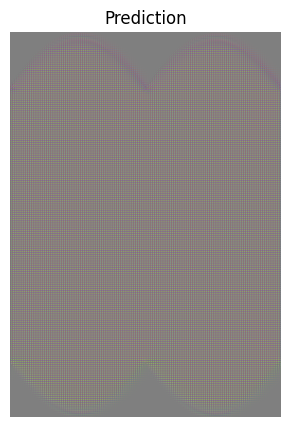

In [71]:
# Remove the batch dimension and single channel dimension from the prediction
# np.squeeze removes dimensions of size 1
prediction_to_plot = np.squeeze(prediction_sinogram)

plt.figure(figsize=(10, 5))
# Display the prediction
plt.subplot(1, 1, 1) # Use 1,1,1 for a single plot
plt.imshow(prediction_to_plot, cmap = plt.cm.Greys_r)
plt.title('Prediction')
plt.axis('off')
plt.show()

### Preparing training and testing datasets

In [72]:
import os
base_dir = '.'
dataset = 'brain_CT'
output_folder = os.path.join(base_dir, dataset)
input_folder = os.path.join(base_dir, f"{dataset}_sinograms")

In [73]:
X = np.ndarray((0, 256, 256, 1), dtype=np.float32)
Y = np.ndarray((0, 256, 256, 3), dtype=np.float32)

In [79]:
import skimage.io as io
import numpy as np
import os

X_list = []
Y_list = []

expected_x_shape = X.shape[1:]
expected_y_shape = Y.shape[1:]

for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        # Read images
        try:
            input_image = io.imread(input_path, as_gray=False)
            output_image = io.imread(output_path)
        except Exception as e:
            print(f"Error reading image files {filename}: {e}")
            continue # Skip to the next file if there's an error reading

        # Add channel dimension if needed (for grayscale images)
        if input_image.ndim == 2:
            input_image = np.expand_dims(input_image, axis=-1)
        if output_image.ndim == 2:
            output_image = np.expand_dims(output_image, axis=-1)

        # for batch
        input_image_with_batch = np.expand_dims(input_image, axis = 0)

        # Check if the image shapes match the expected shapes before appending
        if input_image.shape == expected_x_shape:
            X_list.append(input_image_with_batch)
        else:
            print(f"Skipping input image {filename} due to unexpected shape: {input_image.shape}. Expected: {expected_x_shape}")

        if output_image.shape == expected_y_shape:
            Y_list.append(output_image)
        else:
             print(f"Skipping output image {filename} due to unexpected shape: {output_image.shape}. Expected: {expected_y_shape}")


# Convert lists to numpy arrays
# Only attempt conversion if lists are not empty
if X_list and Y_list:
    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)

    print(f"Loaded {len(X_list)} images into X and {len(Y_list)} images into Y")
    print(f"Shape of X: {X.shape}")
    print(f"Shape of Y: {Y.shape}")
else:
    print("No images with the expected shapes were found.")

Loaded 125 images into X and 125 images into Y
Shape of X: (125, 1, 256, 256, 1)
Shape of Y: (125, 256, 256, 3)


In [80]:
X_train = X[:100]
Y_train = Y[:100]
X_test = X[101:]
Y_test = Y[101:]

In [81]:
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error is a common loss for regression tasks like image reconstruction
    metrics=['mae'] # Mean Absolute Error is a useful metric to see the average pixel difference
)

In [82]:
history = model.fit(X_train, Y_train, epochs=10, batch_size=32)

Epoch 1/10


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "conv2d_2" is incompatible with the layer: expected axis -1 of input shape to have value 1, but received input with shape (None, 1, 256, 256)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 1, 256, 256, 1), dtype=float32)
  • training=True
  • mask=None

In [83]:
prediction = model.predict(X_train[0])

ValueError: Exception encountered when calling Reshape.call().

[1mCannot reshape a tensor with 1048576 elements to shape [1,23296,64] (1490944 elements) for '{{node sequential_1_1/reshape_2_1/Reshape}} = Reshape[T=DT_FLOAT, Tshape=DT_INT32](sequential_1_1/batch_normalization_2_1/batchnorm/add_1, sequential_1_1/reshape_2_1/Reshape/shape)' with input shapes: [1,128,128,64], [3] and with input tensors computed as partial shapes: input[1] = [1,23296,64].[0m

Arguments received by Reshape.call():
  • inputs=tf.Tensor(shape=(1, 128, 128, 64), dtype=float32)